In [1]:
import sys
sys.path.append('../src')

In [12]:
import jax
import jax.numpy as jnp
import os
import numpy as np
from pinn.train import create_train_state
from pinn.cryoet_io import load_mrc_data
from flax.training import checkpoints

### PARAMETERS ###
GRID_SIZE = 64
lambda_1 = 1000000      # Weight for data loss
lambda_2 = 50           # Weight for physics loss
lambda_2_list = [0, 50]
sdf_pretrain="sphere"   # sphere or plane
shape = "bud_04"
flip_ratio=0.15
# wedge_axis='z'
num_collocation = 10000
threshold = 0.8
# step = 0
step = 2000
# step = 10000

str_flip = str(flip_ratio).replace('.', '')


### CREATE TRAIN STATE ###
key = jax.random.PRNGKey(0)
state, _ = create_train_state(key, lambda_1=lambda_1, lambda_2=lambda_2)

### LOAD CHECKPOINT DATA ###
params_star_list = {}
for lambda_2 in lambda_2_list:
    checkpoint_path = os.path.abspath(f"../outputs/logs/{shape}/data_0926/plane/f{str_flip}/lambda_{lambda_1}_{lambda_2}/checkpoint_{step}")
    checkpoint_data = checkpoints.restore_checkpoint(ckpt_dir=checkpoint_path, target=None)
    params_star = checkpoint_data["state"]["params"]
    params_star_list[lambda_2] = params_star

# # checkpoint_path = os.path.abspath(f"../outputs/logs/{shape}/data_0926/plane/f{str_flip}/lambda_{lambda_1}_{lambda_2}/checkpoint_{step}")
# checkpoint_path = os.path.abspath(f"../outputs/logs/{shape}/data_1016/f{str_flip}/lambda_{lambda_1}_{lambda_2}/checkpoint_{step}")
# checkpoint_data = checkpoints.restore_checkpoint(ckpt_dir=checkpoint_path, target=None)
# params_star = checkpoint_data["state"]["params"]

### LOAD MRC DATA ###
# mrc_file_path = f"../data/synthetic/{shape}.mrc"
mrc_file_path = f"../data/synthetic/flip_noise/{shape}_f{str(flip_ratio).replace('.', '')}.mrc"
# mrc_file_path = f"../data/synthetic/flip_noise/{shape}_f{str(flip_ratio).replace('.', '')}_w{wedge_axis}.mrc"
cryoET_data = load_mrc_data(mrc_file_path, grid_size=GRID_SIZE)

### COLLOCATION POINTS ###
x_train = (jax.random.uniform(key, (num_collocation, 3), minval=-1, maxval=1))


Resizing MRC data from (128, 128, 128) to (64, 64, 64)


In [13]:
from pinn.model import loss_data, loss_physics
from pinn.landscape import build_landscape_directions, compute_landscape, plot_contour, plot_contour_log
import matplotlib.pyplot as plt

rng = jax.random.PRNGKey(1)
d1, d2 = build_landscape_directions(params_star, rng)

# a_max = 0.6
# b_max = 0.6
a_max = 1
b_max = 1
n_sample = 30
alphas = np.linspace(-a_max, a_max, n_sample)
betas  = np.linspace(-b_max, b_max, n_sample)

Z_L1 = compute_landscape(state, params_star, d1, d2, alphas, betas, cryoET_data, x_train, loss_data, loss_physics, which="L1")
Z_L2 = compute_landscape(state, params_star, d1, d2, alphas, betas, cryoET_data, x_train, loss_data, loss_physics, which="L2")
# Z_Lfull = compute_landscape(state, params_star, d1, d2, alphas, betas, cryoET_data, x_train, loss_data, loss_physics, which="L_full")
Z_Lfull = Z_L1 + Z_L2

# plot_contour(alphas, betas, Z_L1, "L1 (Data term)")
# plot_contour(alphas, betas, Z_Lfull, "L1 + λ L2 (Full)")
# plt.show()

alpha: 100%|███████████████████████████████████████████████| 30/30 [00:02<00:00, 11.32it/s]


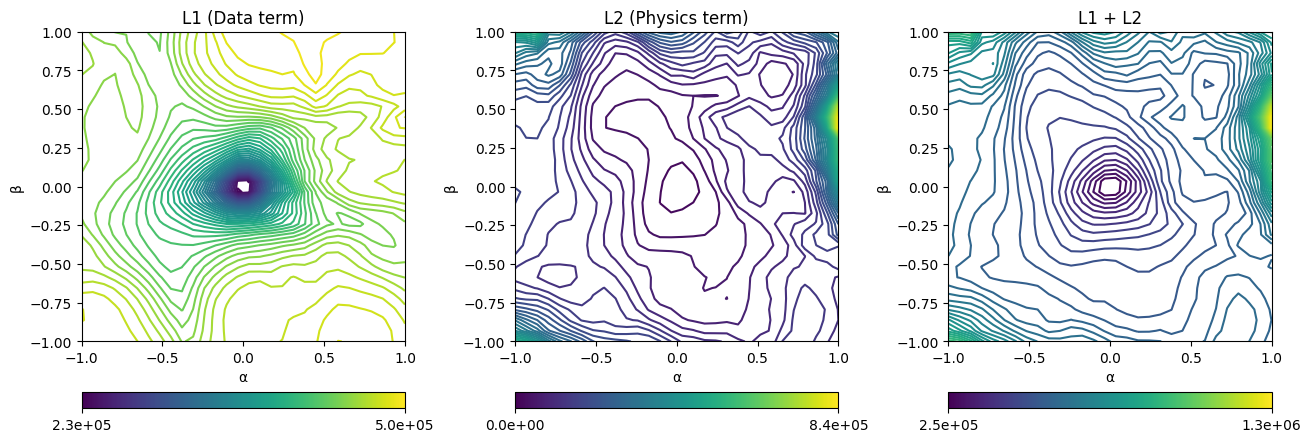

In [14]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(13, 4.3), constrained_layout=True)
levels_num = 50
cmap = 'viridis'

for ax, Z, title in zip(
    axes,
    [Z_L1, Z_L2, Z_Lfull],
    ["L1 (Data term)", "L2 (Physics term)", "L1 + L2"]
):
    # Contour lines (not filled)
    CS = ax.contour(alphas, betas, Z.T, levels=levels_num, cmap=cmap)
    ax.set_title(title)
    ax.set_xlabel("α")
    ax.set_ylabel("β")

    # Continuous colorbar trick
    vmin, vmax = CS.get_array().min(), CS.get_array().max()
    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
    sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])

    # Continuous colorbar below each subplot
    cbar = fig.colorbar(sm, ax=ax, orientation='horizontal', pad=0.02)
    cbar.set_ticks([vmin, vmax])
    cbar.set_ticklabels([f"{vmin:.1e}", f"{vmax:.1e}"])

plt.show()


In [4]:
# Make movie (data accumulation part)

import jax
import jax.numpy as jnp
import os
import numpy as np
from pinn.train import create_train_state
from pinn.cryoet_io import load_mrc_data
from flax.training import checkpoints
from pinn.landscape import build_landscape_directions, compute_landscape
from pinn.model import loss_data, loss_physics
from tqdm import tqdm

### PARAMETERS ###
GRID_SIZE = 64
lambda_1 = 1000000      # Weight for data loss
lambda_2 = 50            # Weight for physics loss
shape = "bud_04"
flip_ratio=0.2
# wedge_axis='z'
num_collocation = 10000
step_series = list(range(0, 10001, 100))
# step_series = list(range(0, 3001, 100))
str_flip = str(flip_ratio).replace('.', '')
a_max = 1
b_max = 1
n_sample = 30
version = "0926/plane"

### CREATE TRAIN STATE ###
key = jax.random.PRNGKey(0)
state, _ = create_train_state(key, lambda_1=lambda_1, lambda_2=lambda_2)

### LOAD MRC DATA ###
# mrc_file_path = f"../data/synthetic/{shape}.mrc"
mrc_file_path = f"../data/synthetic/flip_noise/{shape}_f{str(flip_ratio).replace('.', '')}.mrc"
# mrc_file_path = f"../data/synthetic/flip_noise/{shape}_f{str(flip_ratio).replace('.', '')}_w{wedge_axis}.mrc"
cryoET_data = load_mrc_data(mrc_file_path, grid_size=GRID_SIZE)

### COLLOCATION POINTS ###
x_train = (jax.random.uniform(key, (num_collocation, 3), minval=-1, maxval=1))

### LOAD CHECKPOINT DATA ###
params_star_seq = {}
for step in step_series:
    checkpoint_path = os.path.abspath(f"../outputs/logs/{shape}/data_{version}/f{str_flip}/lambda_{lambda_1}_{lambda_2}/checkpoint_{step}")
    checkpoint_data = checkpoints.restore_checkpoint(ckpt_dir=checkpoint_path, target=None)
    params_star_seq[step] = checkpoint_data["state"]["params"]

### CALCULATE LANDSCAPE ###
rng = jax.random.PRNGKey(1)
alphas = np.linspace(-a_max, a_max, n_sample)
betas  = np.linspace(-b_max, b_max, n_sample)
Z_L1_seq = {}
Z_L2_seq = {}
Z_Lfull_seq = {}
for step in tqdm(step_series):
    d1, d2 = build_landscape_directions(params_star_seq[step], rng)    
    Z_L1 = compute_landscape(state, params_star_seq[step], d1, d2, alphas, betas, cryoET_data, x_train, loss_data, loss_physics, which="L1", show_progress=False)
    Z_L2 = compute_landscape(state, params_star_seq[step], d1, d2, alphas, betas, cryoET_data, x_train, loss_data, loss_physics, which="L2", show_progress=False)
    Z_L1_seq[step] = Z_L1
    Z_L2_seq[step] = Z_L2
    Z_Lfull_seq[step] = Z_L1 + Z_L2


Resizing MRC data from (128, 128, 128) to (64, 64, 64)


100%|████████████████████████████████████████████████████| 101/101 [13:08<00:00,  7.80s/it]


In [5]:
# ============================================================
# Make a movie of the loss landscape evolution
# ============================================================

import os
import re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import imageio

# --------------------------------------------
# Parameters
# --------------------------------------------
log_dir = os.path.abspath(f"../outputs/logs/{shape}/data_{version}/f{str_flip}/lambda_{lambda_1}_{lambda_2}")
frame_dir = os.path.join(log_dir, "landscape")
os.makedirs(frame_dir, exist_ok=True)

levels_num = 50
cmap = "viridis"

# --------------------------------------------
# Helper function: save contour frame
# --------------------------------------------
def save_landscape_frame(step, Z_L1, Z_L2, Z_Lfull, alphas, betas, save_dir="frames"):
    """Plot L1, L2, and L1+L2 contour maps and save as a PNG frame."""
    fig, axes = plt.subplots(1, 3, figsize=(13, 4.3), constrained_layout=True)

    for ax, Z, title in zip(
        axes,
        [Z_L1, Z_L2, Z_Lfull],
        ["L1 (Data term)", "L2 (Physics term)", "L1 + L2"]
    ):
        # Contour lines (not filled)
        CS = ax.contour(alphas, betas, Z.T, levels=levels_num, cmap=cmap)
        # ax.set_title(title)
        ax.set_title(f"{title}, step {step}", fontsize=12)
        
        ax.set_xlabel("α")
        ax.set_ylabel("β")

        # Continuous colorbar
        vmin, vmax = CS.get_array().min(), CS.get_array().max()
        norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
        sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
        sm.set_array([])

        cbar = fig.colorbar(sm, ax=ax, orientation='horizontal', pad=0.02)
        cbar.set_ticks([vmin, vmax])
        cbar.set_ticklabels([f"{vmin:.1e}", f"{vmax:.1e}"])

    # fig.suptitle(f"Loss landscape at step {step}", y=1.02, fontsize=12)

    os.makedirs(save_dir, exist_ok=True)
    filename = os.path.join(save_dir, f"frame_{step:06d}.png")
    plt.savefig(filename, dpi=150)
    plt.close(fig)

# --------------------------------------------
# Helper function: compile movie
# --------------------------------------------
def make_movie_from_frames(frame_dir="frames", output="movie.mp4", fps=12, start=0, end=30000):
    """Combine saved PNG frames into an MP4 movie."""
    pattern = re.compile(r"frame_(\d+)\.png")

    frames = []
    for fname in os.listdir(frame_dir):
        match = pattern.match(fname)
        if match:
            index = int(match.group(1))
            if start <= index <= end:
                frames.append((index, os.path.join(frame_dir, fname)))

    frames.sort(key=lambda x: x[0])

    with imageio.get_writer(output, fps=fps) as writer:
        for idx, frame_path in frames:
            image = imageio.imread(frame_path)
            writer.append_data(image)
            print(f"Appending frame {idx}")

# --------------------------------------------
# Main loop
# --------------------------------------------
for step in tqdm(step_series):
    # print(f"Saving step {step}")
    save_landscape_frame(step, Z_L1_seq[step], Z_L2_seq[step], Z_Lfull_seq[step], alphas, betas, save_dir=frame_dir)

# --------------------------------------------
# Build movie
# --------------------------------------------
output = os.path.abspath(f"{frame_dir}/movie.mp4")
make_movie_from_frames(frame_dir=frame_dir, output=output)
print(f"Movie saved to {output}")


100%|████████████████████████████████████████████████████| 101/101 [01:30<00:00,  1.11it/s]
/tmp/ipykernel_69708/3958180845.py:78: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread(frame_path)
/gscratch/matsulab/envs/pinn-env/lib/python3.12/subprocess.py:1885: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = _fork_exec(


Appending frame 0
Appending frame 100
Appending frame 200
Appending frame 300
Appending frame 400
Appending frame 500
Appending frame 600
Appending frame 700
Appending frame 800
Appending frame 900
Appending frame 1000
Appending frame 1100
Appending frame 1200
Appending frame 1300
Appending frame 1400
Appending frame 1500
Appending frame 1600
Appending frame 1700
Appending frame 1800
Appending frame 1900
Appending frame 2000
Appending frame 2100
Appending frame 2200
Appending frame 2300
Appending frame 2400
Appending frame 2500
Appending frame 2600
Appending frame 2700
Appending frame 2800
Appending frame 2900
Appending frame 3000
Appending frame 3100
Appending frame 3200
Appending frame 3300
Appending frame 3400
Appending frame 3500
Appending frame 3600
Appending frame 3700
Appending frame 3800
Appending frame 3900
Appending frame 4000
Appending frame 4100
Appending frame 4200
Appending frame 4300
Appending frame 4400
Appending frame 4500
Appending frame 4600
Appending frame 4700
Appe

In [51]:
def plot_contour(alphas, betas, Z, title):
    vmin = 3000
    vmax = 1e6 + 2e5
    plt.figure(figsize=(6,5))
    levels = np.linspace(vmin, vmax, 50)
    CS = plt.contourf(alphas, betas, Z.T, levels=levels, vmin=vmin, vmax=vmax)
    # CS = plt.contourf(alphas, betas, Z.T, levels=50, vmin=1e1, vmax=1e5)
    plt.colorbar(CS, label="Loss")
    plt.xlabel("α")
    plt.ylabel("β")
    plt.title(title)
    plt.tight_layout()

In [57]:
def plot_contour_log(alphas, betas, Z, title):
    vmin = 3000
    vmax = 7e5
    levels = np.linspace(vmin, vmax, 50)
    Zlog = np.log1p(np.maximum(Z - np.nanmin(Z), 0.0))  # shift & log(1+)
    plt.figure(figsize=(6,5))
    CS = plt.contourf(alphas, betas, Zlog.T, levels=levels, vmin=vmin, vmax=vmax)
    plt.colorbar(CS, label="log(1 + shifted loss)")
    plt.xlabel("α"); plt.ylabel("β"); plt.title(title); plt.tight_layout()

‖VᵀV - I‖: 4.596404778567376e-06
max |rq - λ|: 1.7870079318527132e-06
min cosine(Hv, λv): 8.961705316323787e-05
‖VᵀV - I‖: 4.3254294723737985e-06
max |rq - λ|: 7.450580596923828e-08
min cosine(Hv, λv): 0.0010986113920807838
‖VᵀV - I‖: 4.234250809531659e-06
max |rq - λ|: 3.814697265625e-06
min cosine(Hv, λv): 0.1279754787683487


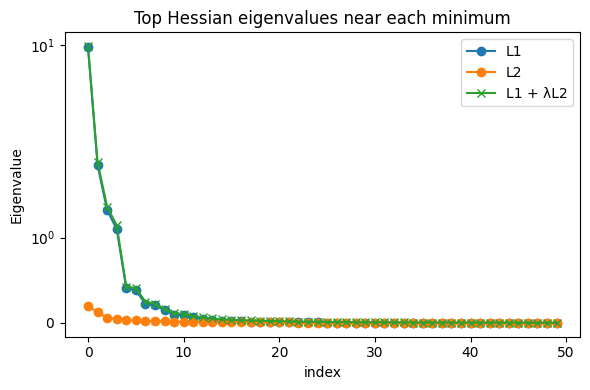

In [5]:
from pinn.landscape import hessian_spectrum_topk, compute_hessian_spectrum, topk_hessian_eigs, ritz_residuals
from pinn.model import loss_data, loss_physics
import matplotlib.pyplot as plt

# Choose the reference points (around each minimum)
params_L1_star   = params_star_list[0] 
params_full_star = params_star_list[50]

# Top-k eigenvalues near each minimum
# evals_L1,   _ = hessian_spectrum_topk(params_L1_star,   state, cryoET_data, x_train,
#                                       loss_data, loss_physics, which="L1",     k=30, rng_key=0)
# # evals_L1,   _ = hessian_spectrum_topk(params_full_star, state, cryoET_data, x_train,
#                                       # loss_data, loss_physics, which="L1",     k=30, rng_key=0)
# evals_full, _ = hessian_spectrum_topk(params_full_star, state, cryoET_data, x_train,
#                                       loss_data, loss_physics, which="L_full", k=30, rng_key=1)

# evals_full, _ = compute_hessian_spectrum(params_full_star, state, cryoET_data, x_train, loss_data, loss_physics, topk=None)


key = jax.random.PRNGKey(0)

# state, _ = create_train_state(key, lambda_1=lambda_1, lambda_2=0)
# evals_L1  , _ = topk_hessian_eigs(params_L1_star  , state, cryoET_data, x_train, loss_data, loss_physics, k=20)

state, _ = create_train_state(key, lambda_1=lambda_1, lambda_2=0)
evals_L1  , _ , _ , _ = topk_hessian_eigs(params_full_star  , state, cryoET_data, x_train, loss_data, loss_physics, k=50)

state, _ = create_train_state(key, lambda_1=0, lambda_2=50)
evals_L2  , _ , _ , _ = topk_hessian_eigs(params_full_star  , state, cryoET_data, x_train, loss_data, loss_physics, k=50)

state, _ = create_train_state(key, lambda_1=lambda_1, lambda_2=50)
evals_full, _ , _ , _ = topk_hessian_eigs(params_full_star, state, cryoET_data, x_train, loss_data, loss_physics, k=50)

# eigvals, eigvecs, abs_res, rel_res = topk_hessian_eigs(params_full_star, state, cryoET_data, x_train, loss_data, loss_physics, k=10, iters=80, block=None)

# res, rel_res = ritz_residuals(params_full_star, state, cryoET_data, x_train, loss_data, loss_physics, eigvals, eigvecs)
# print("abs residuals:", abs_res)
# print("rel residuals:", rel_res)

plt.figure(figsize=(6,4))
# plt.plot(evals_L1[:20],   marker='o', label='L1 (top 20)')
# plt.plot(evals_full[:20], marker='x', label='L1 + λL2 (top 20)')
plt.plot(evals_L1,   marker='o', label='L1')
plt.plot(evals_L2,   marker='o', label='L2')
plt.plot(evals_full, marker='x', label='L1 + λL2')
# plt.plot(eigvals, marker='x', label='L1 + λL2')

plt.yscale('symlog')  # curvature can vary a lot; symlog is often nice
plt.xlabel('index'); plt.ylabel('Eigenvalue')
plt.title('Top Hessian eigenvalues near each minimum')
plt.legend(); plt.tight_layout(); plt.show()

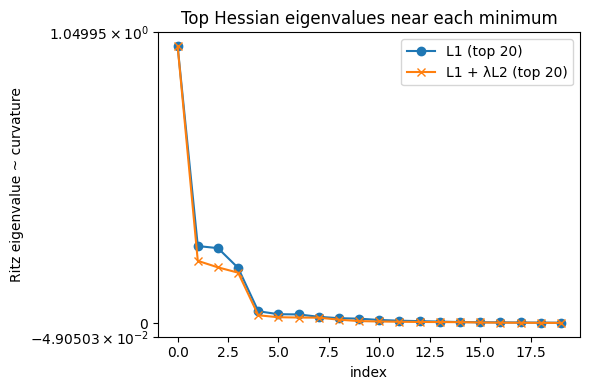

In [16]:
evals_L1_norm   = evals_L1 / (np.max(evals_L1)   + 1e-12)
evals_full_norm = evals_full / (np.max(evals_full)+ 1e-12)

plt.figure(figsize=(6,4))
plt.plot(evals_L1_norm[:20],   marker='o', label='L1 (top 20)')
plt.plot(evals_full_norm[:20], marker='x', label='L1 + λL2 (top 20)')
plt.yscale('symlog')  # curvature can vary a lot; symlog is often nice
plt.xlabel('index'); plt.ylabel('Ritz eigenvalue ~ curvature')
plt.title('Top Hessian eigenvalues near each minimum')
plt.legend(); plt.tight_layout(); plt.show()